<a href="https://colab.research.google.com/github/Smriti-kinra/DL-lab-2/blob/main/run_pet_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Oxford-IIIT Pet — Multi-Task CNN (Q1 + Q2)

Run this from the `pet_project` root folder (the one containing `src/`, `README.md`, `requirements.txt`).
In VS Code: select a Python interpreter/kernel that has `torch`/`torchvision` installed (or install below),
then run cells top to bottom.

- **Q1** deliverables (architecture, single-model classification+segmentation results) come from the
  `none`-augmentation run below — it's the same model, so it doubles as both Q1's model and Experiment A of Q2.
- **Q2** deliverables (the 3-experiment comparison) come from running all three augmentation modes.


## 0. Setup

Works seamlessly **locally in VS Code** and on **Google Colab** (with T4 GPU).


In [2]:
# Google Colab Setup: Automatically handles upload and unzipping on Colab
# (If running locally on your Mac, this cell simply skips automatically)
import sys, os

if "google.colab" in sys.modules:
    print("Detected Google Colab environment.")
    if not os.path.exists("src"):
        from google.colab import files
        print("Please select pet_multitask_project.zip when prompted:")
        uploaded = files.upload()
        for fname in uploaded.keys():
            if fname.endswith(".zip"):
                get_ipython().system(f"unzip -o -q {fname}")
        if os.path.exists("pet_project/src"):
            os.chdir("pet_project")
    print("Working directory:", os.getcwd())
    assert os.path.exists("src"), "Error: src folder not found. Please upload pet_multitask_project.zip"


Detected Google Colab environment.
Please select pet_multitask_project.zip when prompted:


Saving pet_multitask_project.zip to pet_multitask_project.zip
Working directory: /content


In [3]:
# Dependencies are already configured. If needed, uncomment to install:
# %pip install -r requirements.txt


In [4]:
import sys, os, subprocess, json as _json
from pathlib import Path

# Automatically locate the pet_project folder
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    for candidate in [PROJECT_ROOT, PROJECT_ROOT.parent, PROJECT_ROOT / "pet_project"]:
        if (candidate / "src").exists():
            PROJECT_ROOT = candidate
            os.chdir(PROJECT_ROOT)
            break

SRC_DIR = PROJECT_ROOT / "src"
assert SRC_DIR.exists(), f"Expected {SRC_DIR} to exist -- open this notebook from the pet_project folder."
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import torch
print("Python executable:", sys.executable)
print("PyTorch version:", torch.__version__)
print("CUDA available (Colab GPU):", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Device:", torch.cuda.get_device_name(0))
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    print("MPS (Apple Silicon GPU) available: True -> Apple GPU will be used!")


Python executable: /usr/bin/python3
PyTorch version: 2.11.0+cu128
CUDA available (Colab GPU): True
GPU Device: Tesla T4


## 1. Get the dataset

Uses torchvision's built-in downloader (maintained mirror) rather than the torrent -- simpler and works headless. Skips automatically if already downloaded.

In [5]:
from torchvision.datasets import OxfordIIITPet

DATA_ROOT = PROJECT_ROOT / "oxford-iiit-pet"   # torchvision creates <root>/oxford-iiit-pet/{images,annotations}

if not (DATA_ROOT / "images").exists():
    print("Downloading (this fetches images.tar.gz + annotations.tar.gz, ~800MB total)...")
    OxfordIIITPet(root=str(PROJECT_ROOT), split="trainval", download=True)
    OxfordIIITPet(root=str(PROJECT_ROOT), split="test", download=True)
else:
    print("Dataset already present at", DATA_ROOT)

print("images:", len(list((DATA_ROOT / "images").glob("*.jpg"))))
print("trimaps:", len(list((DATA_ROOT / "annotations" / "trimaps").glob("*.png"))))


100%|██████████| 792M/792M [00:41<00:00, 19.0MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 10.7MB/s]


images: 7390
trimaps: 14780


## 2. Config

Do a fast sanity pass first (`EPOCHS = 2`) to confirm everything runs on your machine before
committing to a long run. Bump it up once that finishes cleanly.

In [6]:
IMG_SIZE = 128
EPOCHS = 2          # <-- set to 2 for a quick sanity check, then raise (e.g. 30) for real results
BATCH_SIZE = 32
LR = 1e-3
OUT_DIR = PROJECT_ROOT / "runs"
NUM_WORKERS = 2      # 0 if you hit multiprocessing issues on Windows/VS Code


## 3. Train

### Option A -- run all three experiments (recommended)
This runs Experiment A (no augmentation, = your Q1 model), B (geometric), C (geometric+appearance)
back to back and writes the Q2 comparison table.

In [7]:
cmd = [
    sys.executable, "-u", str(SRC_DIR / "run_all_experiments.py"),
    "--data_root", str(DATA_ROOT),
    "--img_size", str(IMG_SIZE),
    "--epochs", str(EPOCHS),
    "--batch_size", str(BATCH_SIZE),
    "--lr", str(LR),
    "--out_dir", str(OUT_DIR),
]
print(" ".join(cmd))

# Streams output live into the notebook cell as training progresses.
process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
for line in process.stdout:
    print(line, end="")
process.wait()
print("\nExit code:", process.returncode)


/usr/bin/python3 -u /content/src/run_all_experiments.py --data_root /content/oxford-iiit-pet --img_size 128 --epochs 2 --batch_size 32 --lr 0.001 --out_dir /content/runs
Running: /usr/bin/python3 /content/src/train.py --data_root /content/oxford-iiit-pet --aug none --img_size 128 --epochs 2 --batch_size 32 --lr 0.001 --num_workers 2 --seed 42 --out_dir /content/runs/expA_baseline
[none] device=cuda
Trainable parameters: 20,695,526
epoch 001/2 train_loss=4.0103 val_loss=3.9009 val_acc=0.063 val_iou=0.631 val_dice=0.763
epoch 002/2 train_loss=3.8304 val_loss=3.8079 val_acc=0.054 val_iou=0.657 val_dice=0.782
Training done in 1.3 min. Loading best checkpoint for test eval.
TEST  acc=0.0482  mean_IoU=0.6623  mean_Dice=0.7851
All outputs written to /content/runs/expA_baseline
Running: /usr/bin/python3 /content/src/train.py --data_root /content/oxford-iiit-pet --aug geometric --img_size 128 --epochs 2 --batch_size 32 --lr 0.001 --num_workers 2 --seed 42 --out_dir /content/runs/expB_geometric


### Option B -- run one experiment at a time
Use this instead of the cell above if you want to inspect/stop between experiments,
or only need to (re)run one of them.

In [8]:
def run_one(aug_mode, subdir):
    out = OUT_DIR / subdir
    cmd = [
        sys.executable, "-u", str(SRC_DIR / "train.py"),
        "--data_root", str(DATA_ROOT),
        "--aug", aug_mode,
        "--img_size", str(IMG_SIZE),
        "--epochs", str(EPOCHS),
        "--batch_size", str(BATCH_SIZE),
        "--lr", str(LR),
        "--num_workers", str(NUM_WORKERS),
        "--out_dir", str(out),
    ]
    print(" ".join(cmd))
    p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    for line in p.stdout:
        print(line, end="")
    p.wait()
    print("\nExit code:", p.returncode)
    return out

# Uncomment the one(s) you want to (re)run:
# run_one("none", "expA_baseline")
# run_one("geometric", "expB_geometric")
# run_one("geometric_appearance", "expC_geometric_appearance")


## 4. Results table (Question 2)

In [9]:
table_path = OUT_DIR / "results_table.md"
if table_path.exists():
    print(table_path.read_text())
else:
    print("Not found yet -- run section 3 first.")


| Experiment | Classification Accuracy | Mean IoU | Mean Dice |
|---|---|---|---|
| No Augmentation | 0.0482 | 0.6623 | 0.7851 |
| Geometric Augmentation | 0.0510 | 0.6250 | 0.7533 |
| Geometric + Appearance Augmentation | 0.0409 | 0.6344 | 0.7618 |



## 5. Q1 deliverables (from the no-augmentation / Experiment A run)

{
  "aug_mode": "none",
  "n_trainable_params": 20695526,
  "train_time_minutes": 1.3206728498140972,
  "config": {
    "data_root": "/content/oxford-iiit-pet",
    "aug": "none",
    "img_size": 128,
    "epochs": 2,
    "batch_size": 32,
    "lr": 0.001,
    "weight_decay": 0.0001,
    "w_cls": 1.0,
    "w_seg": 1.0,
    "num_workers": 2,
    "out_dir": "/content/runs/expA_baseline",
    "seed": 42
  },
  "test_accuracy": 0.048242028802633286,
  "test_mean_iou": 0.6622901558876038,
  "test_mean_dice": 0.7850702404975891
}

Loss curves:


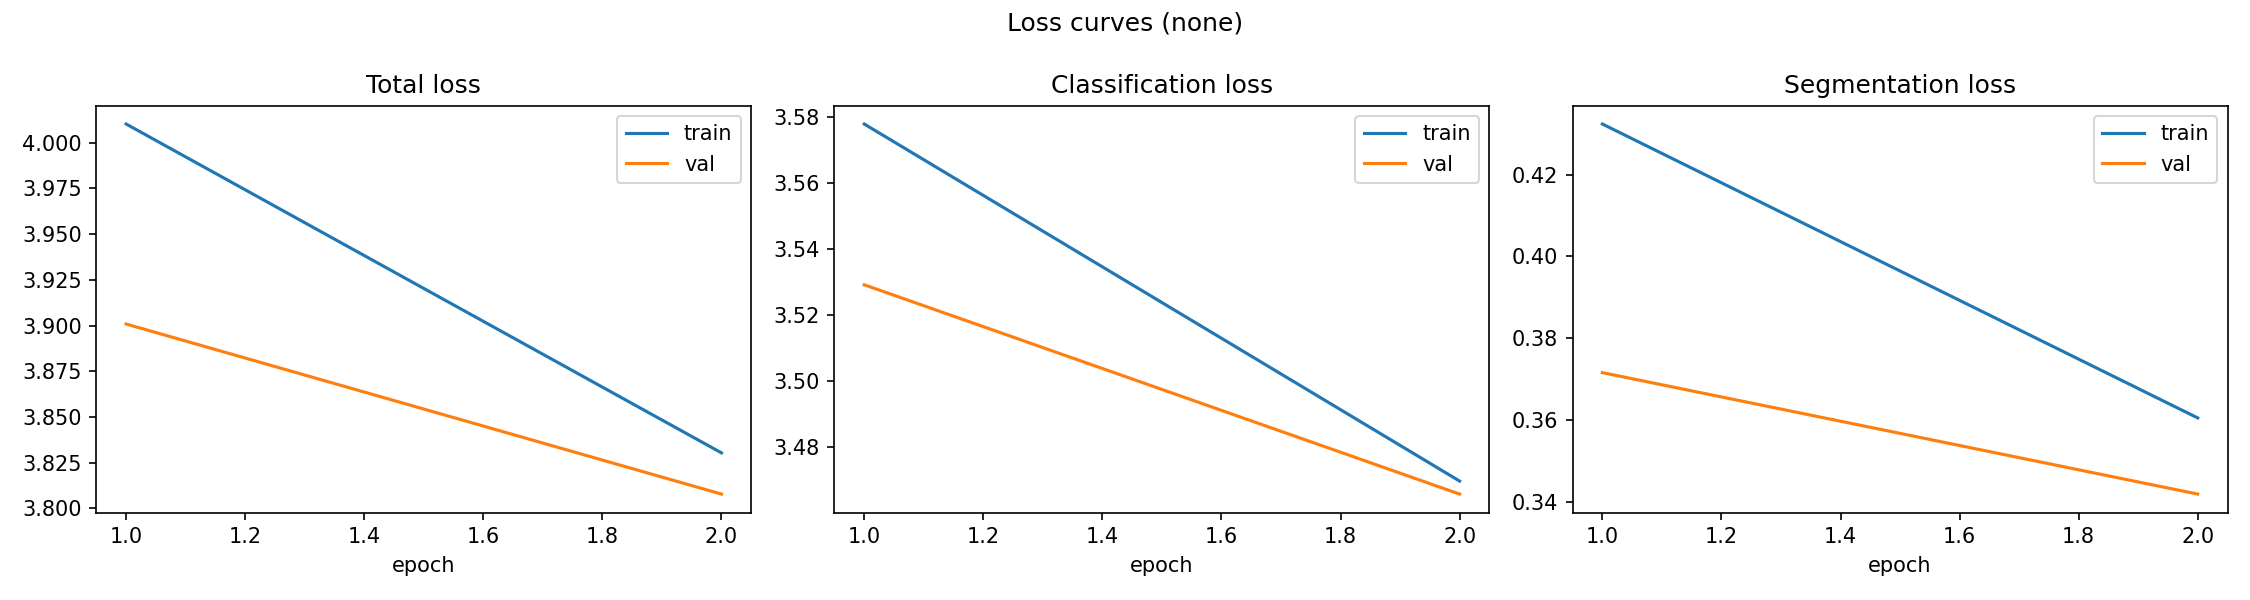

Confusion matrix:


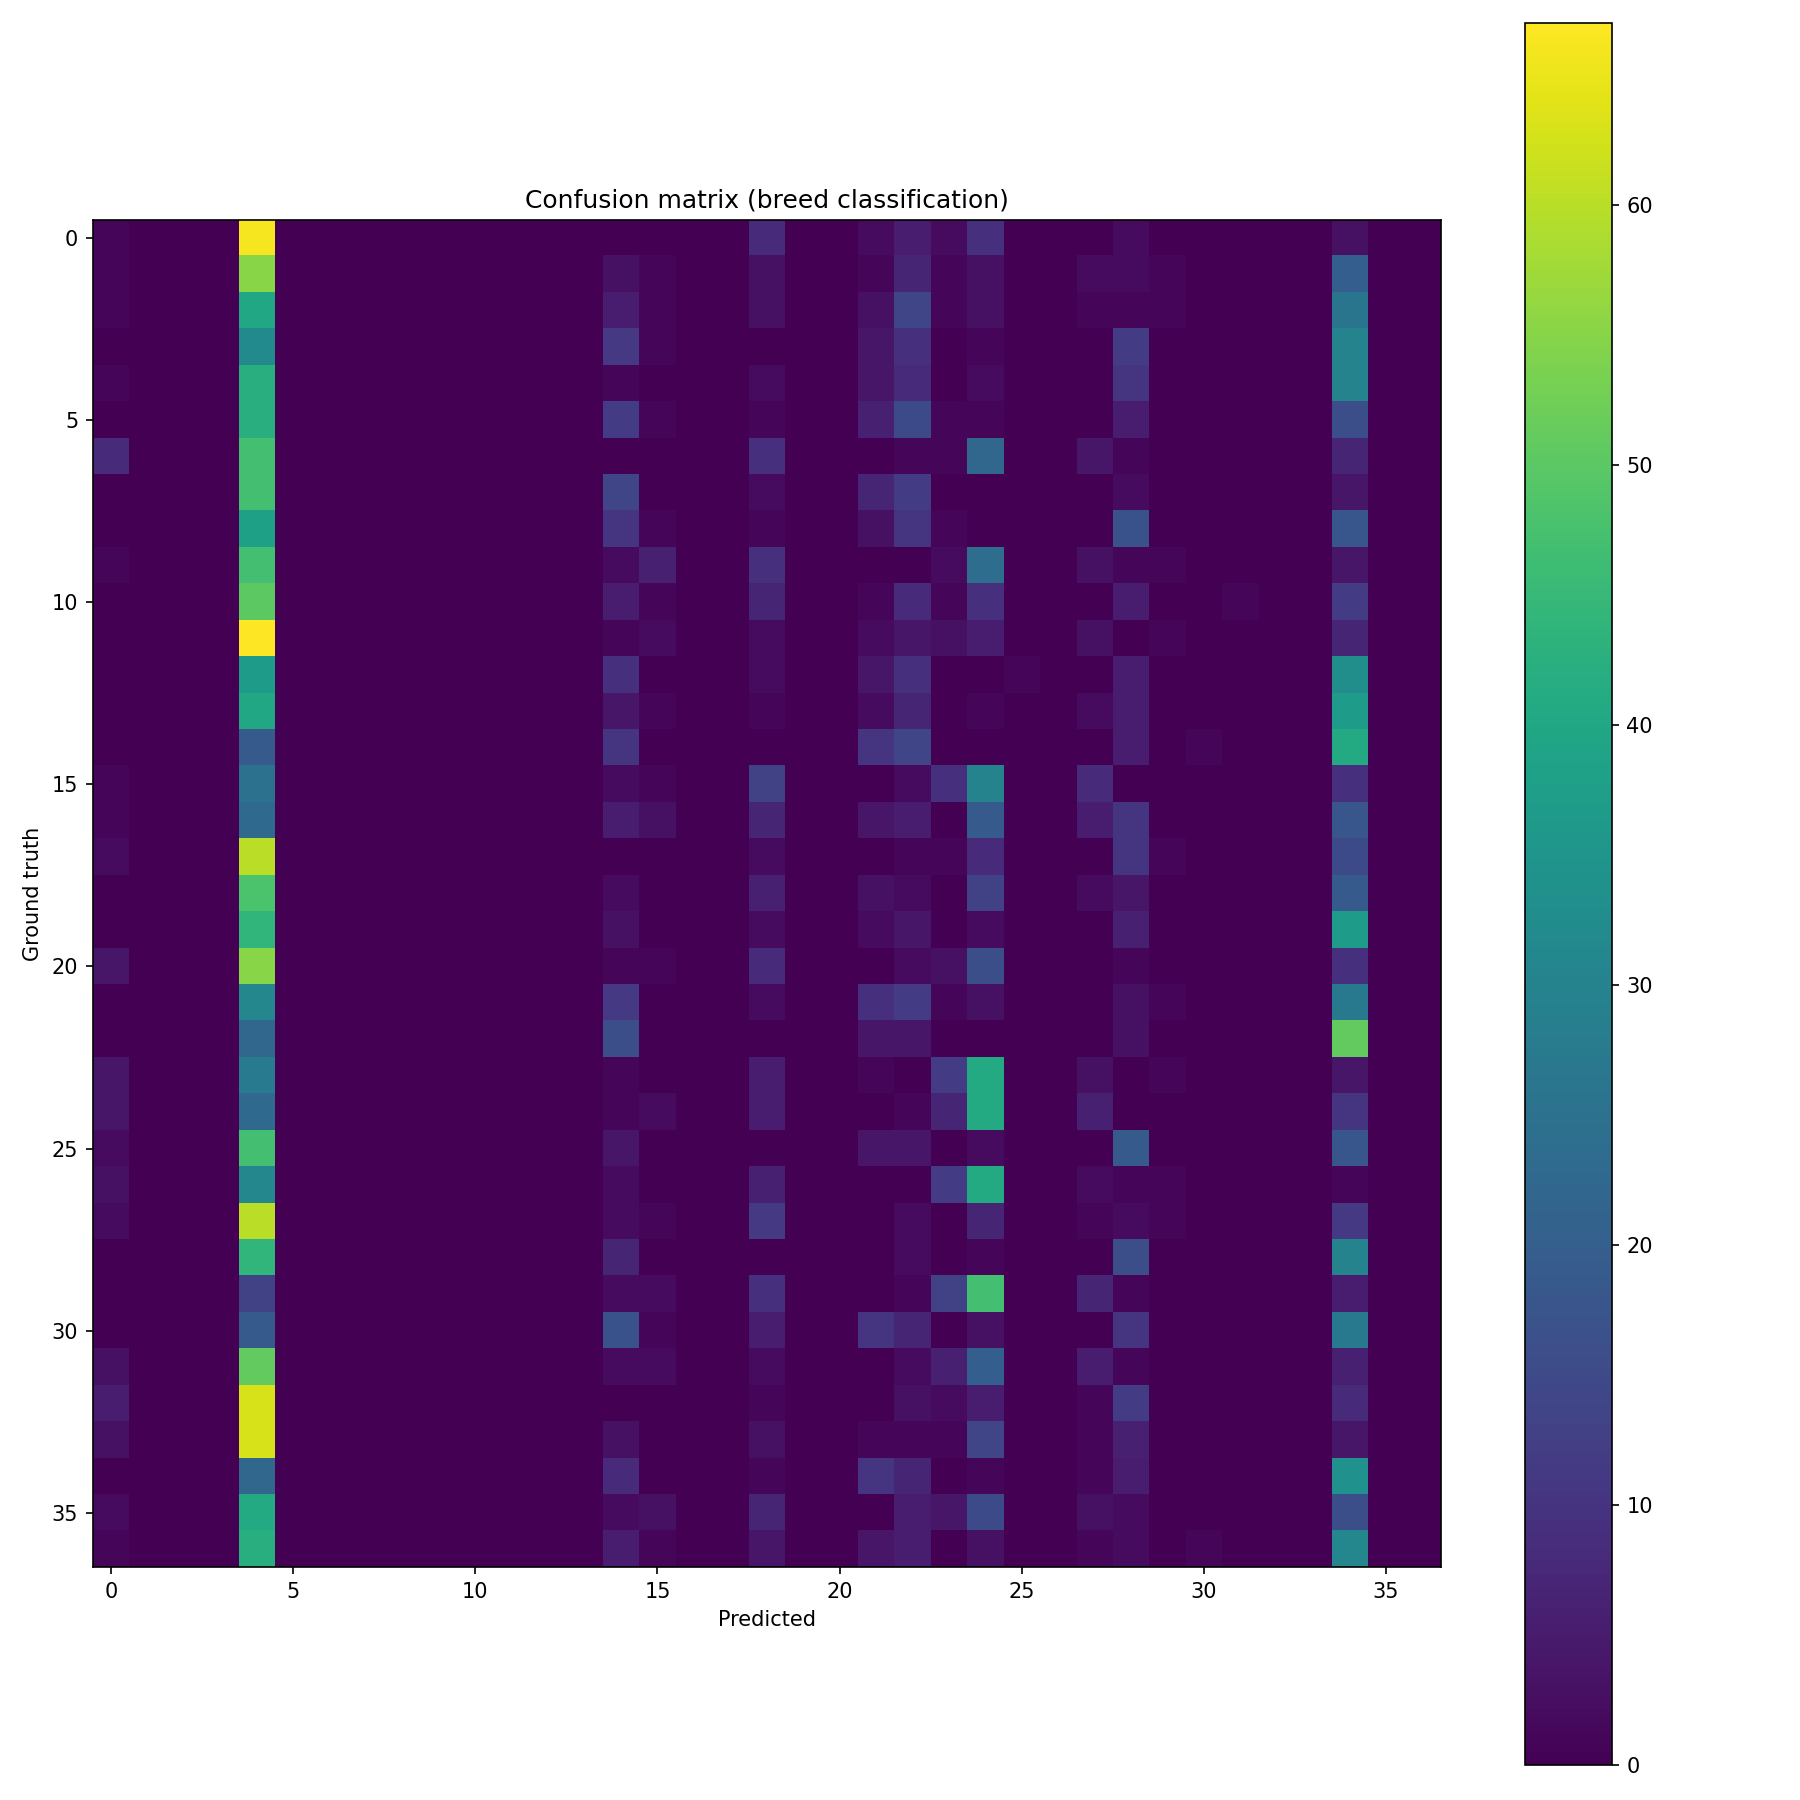

Qualitative segmentation (2 worst-IoU, 3 best-IoU):


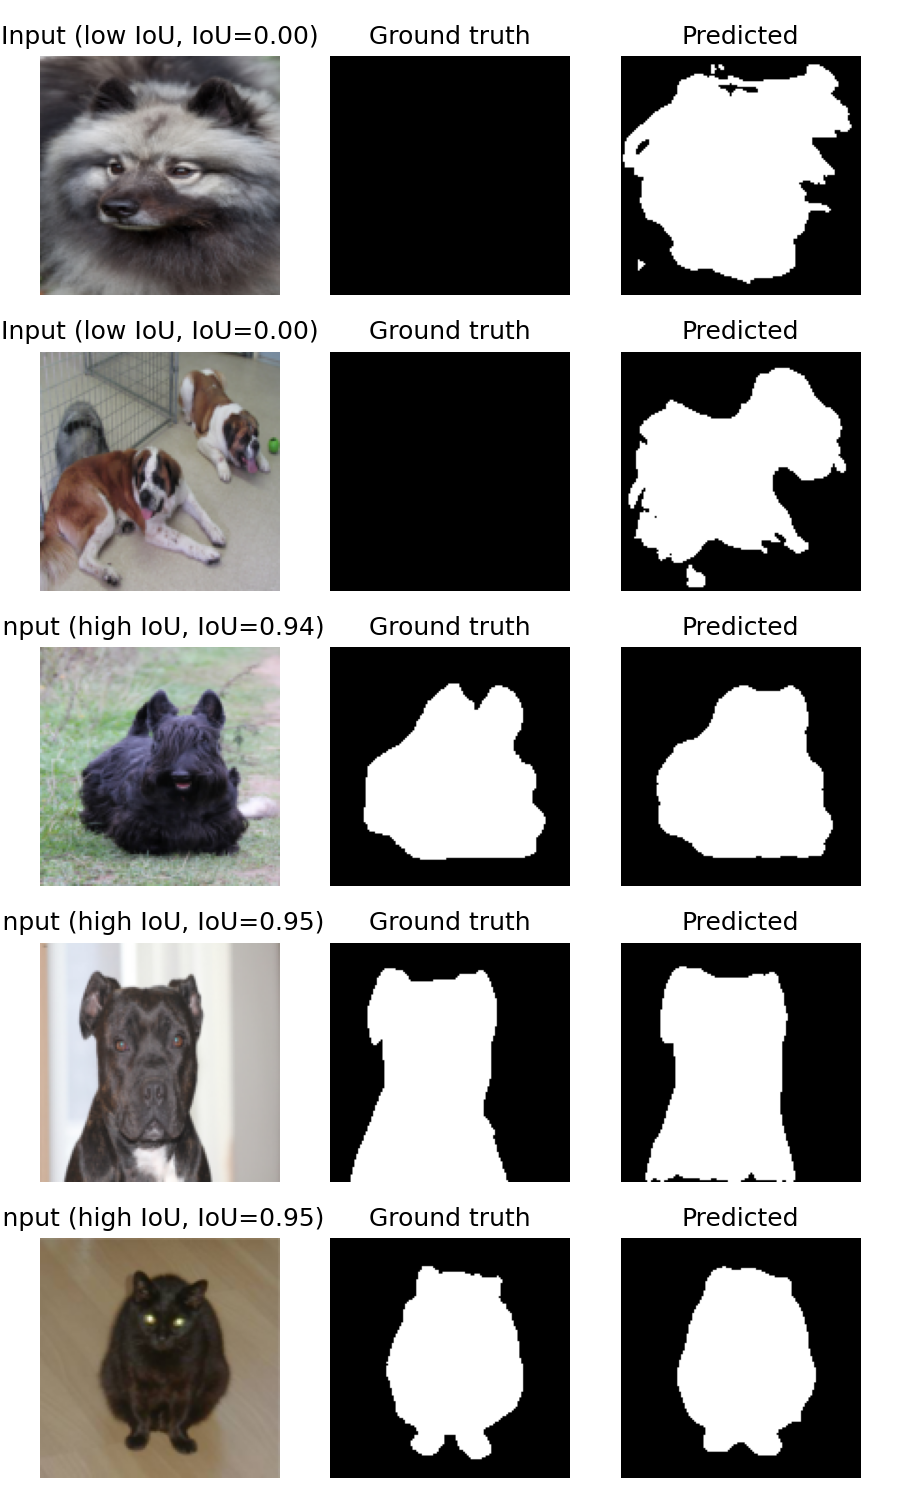

In [10]:
from IPython.display import Image, display, JSON

expA = OUT_DIR / "expA_baseline"

with open(expA / "summary.json") as f:
    summary = _json.load(f)
print(_json.dumps(summary, indent=2))

print("\nLoss curves:")
display(Image(filename=str(expA / "loss_curves.png")))

print("Confusion matrix:")
display(Image(filename=str(expA / "confusion_matrix.png")))

print("Qualitative segmentation (2 worst-IoU, 3 best-IoU):")
display(Image(filename=str(expA / "qualitative_segmentation.png")))


## 6. Q2 deliverables (augmented samples + per-experiment curves)

=== expA_baseline ===


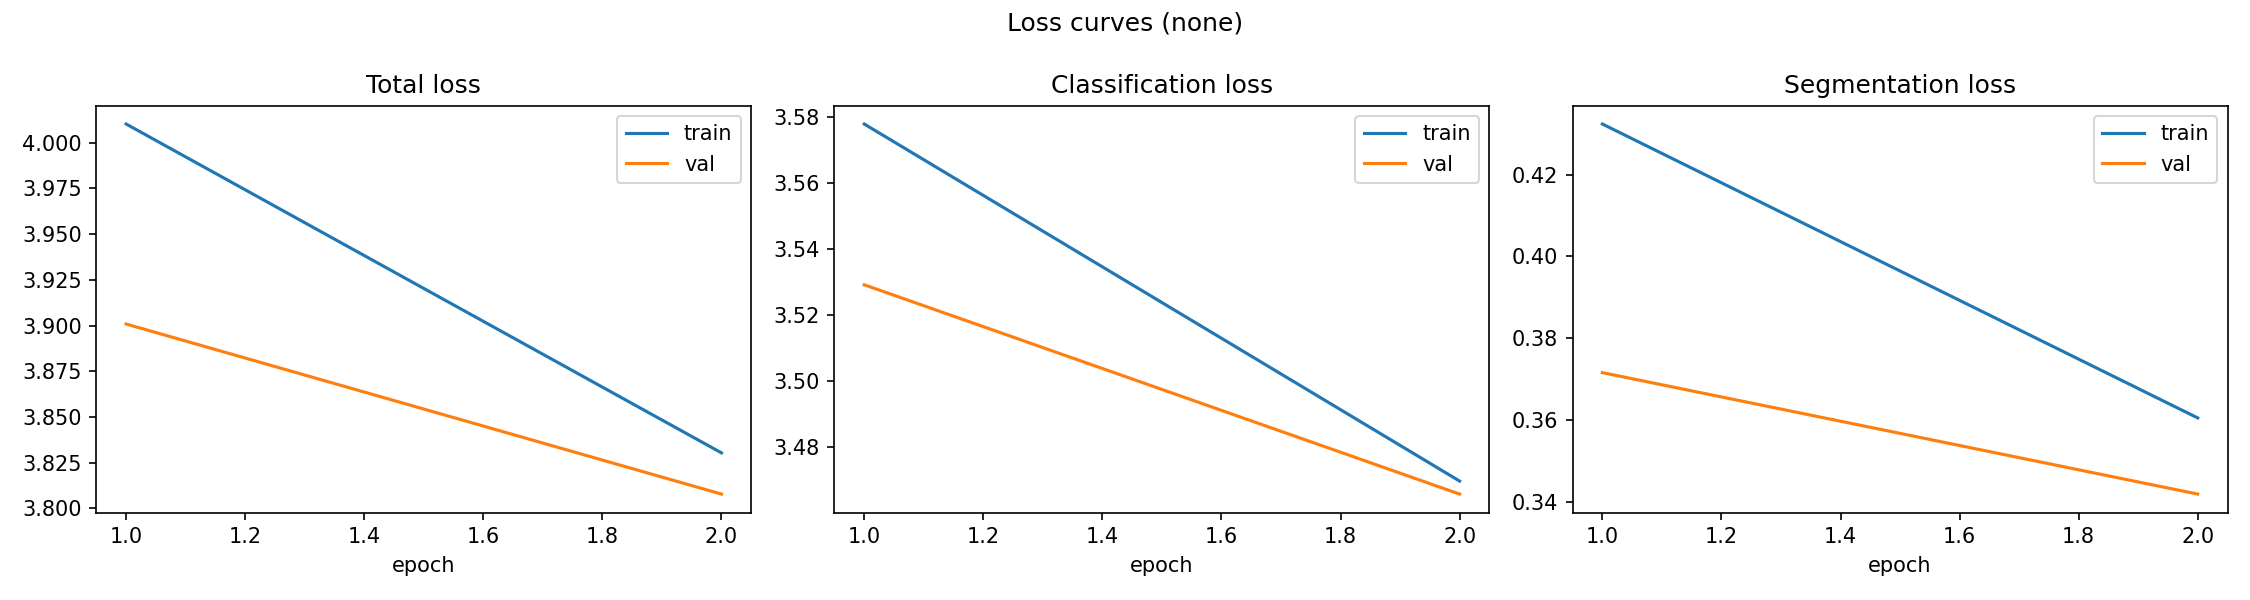

=== expB_geometric ===


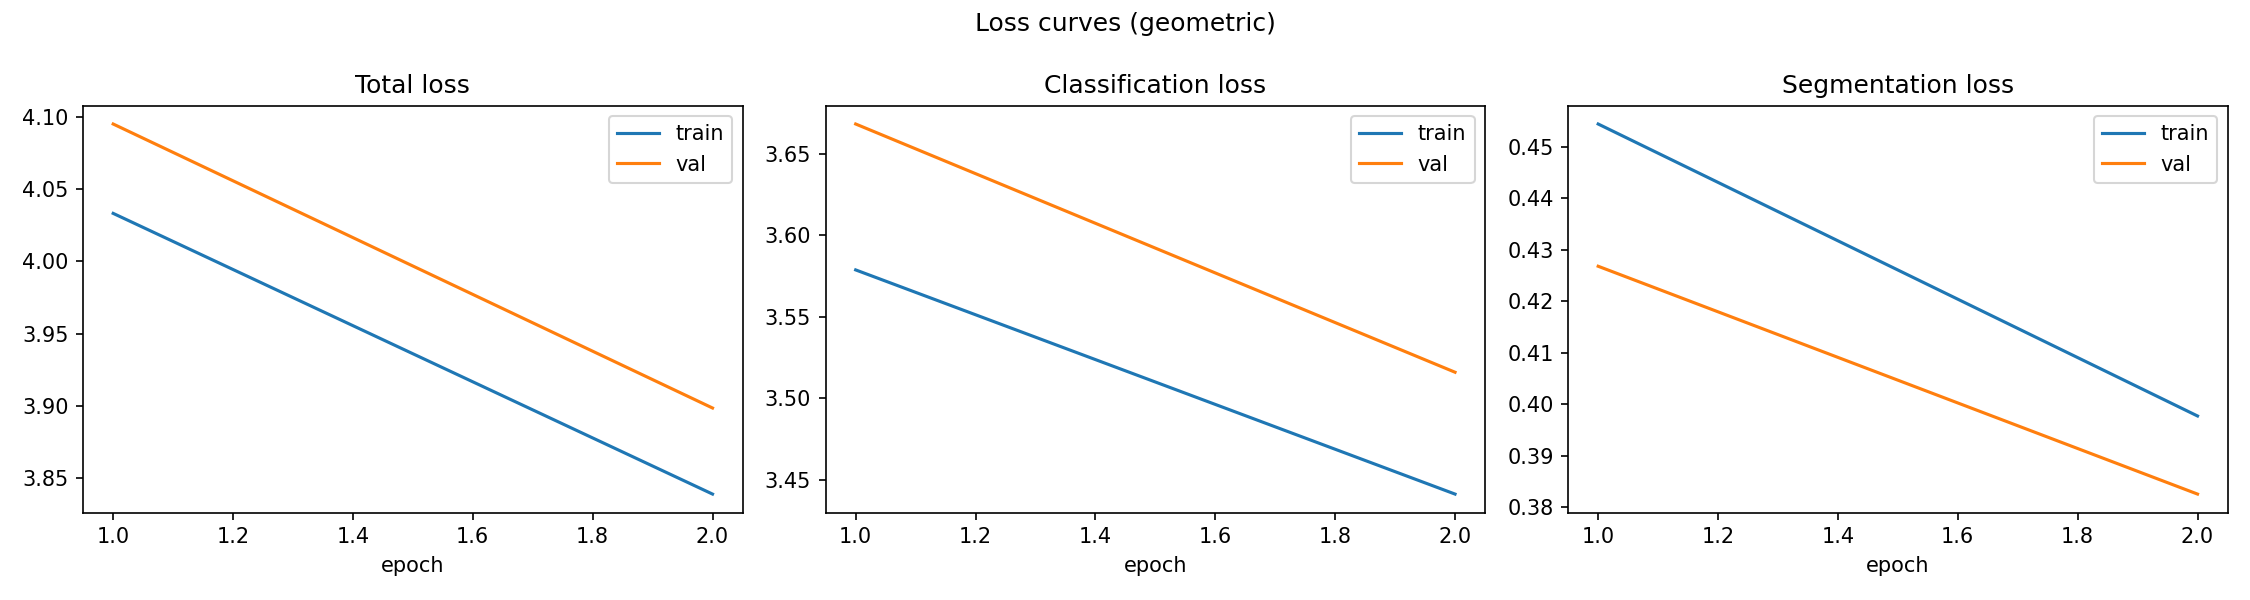

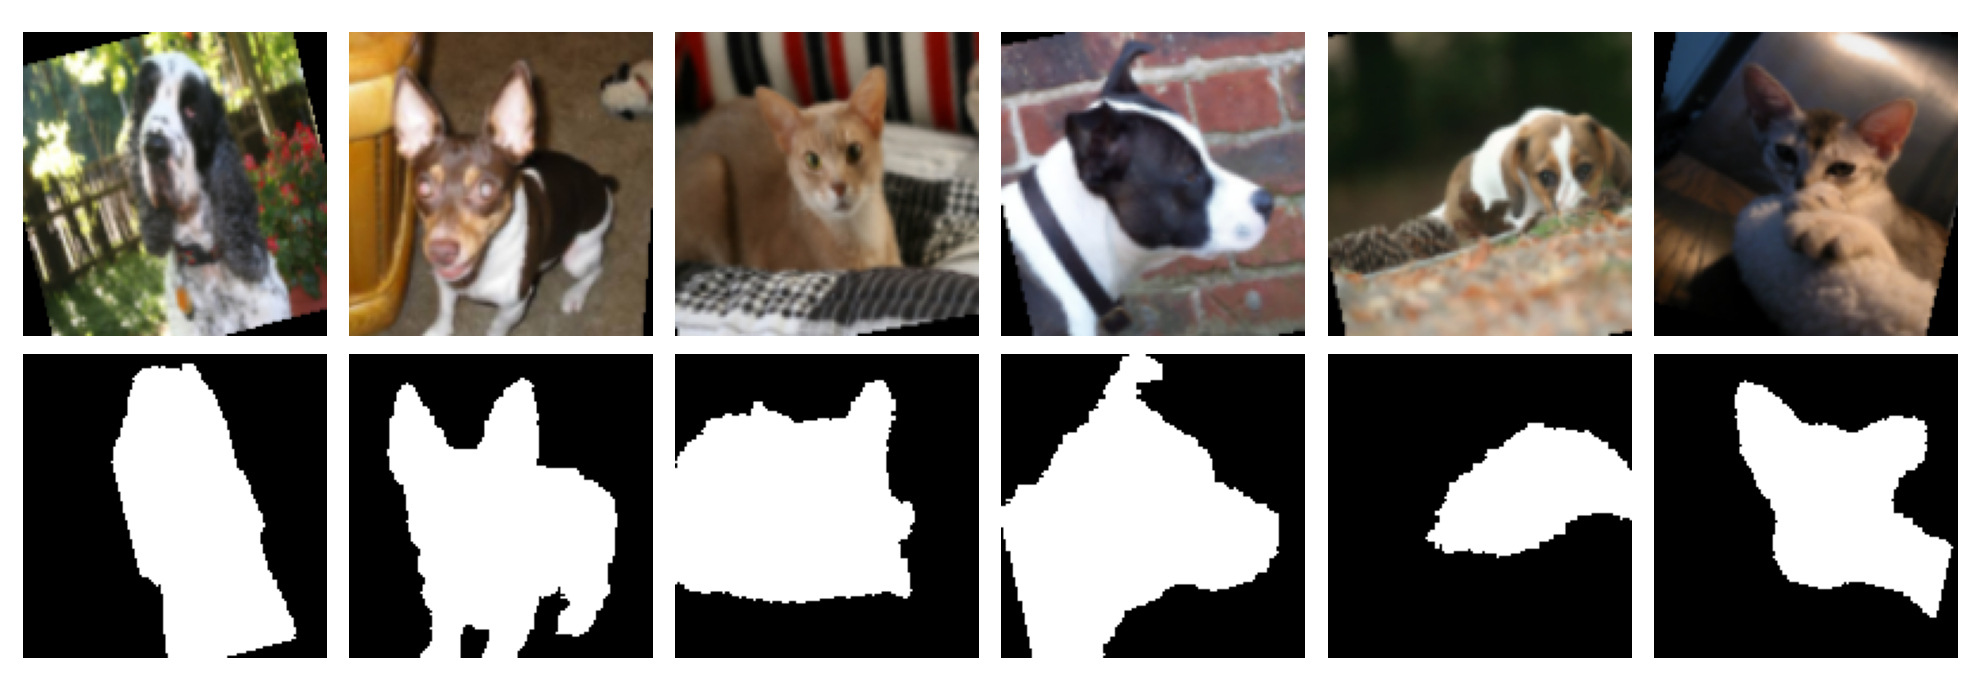

=== expC_geometric_appearance ===


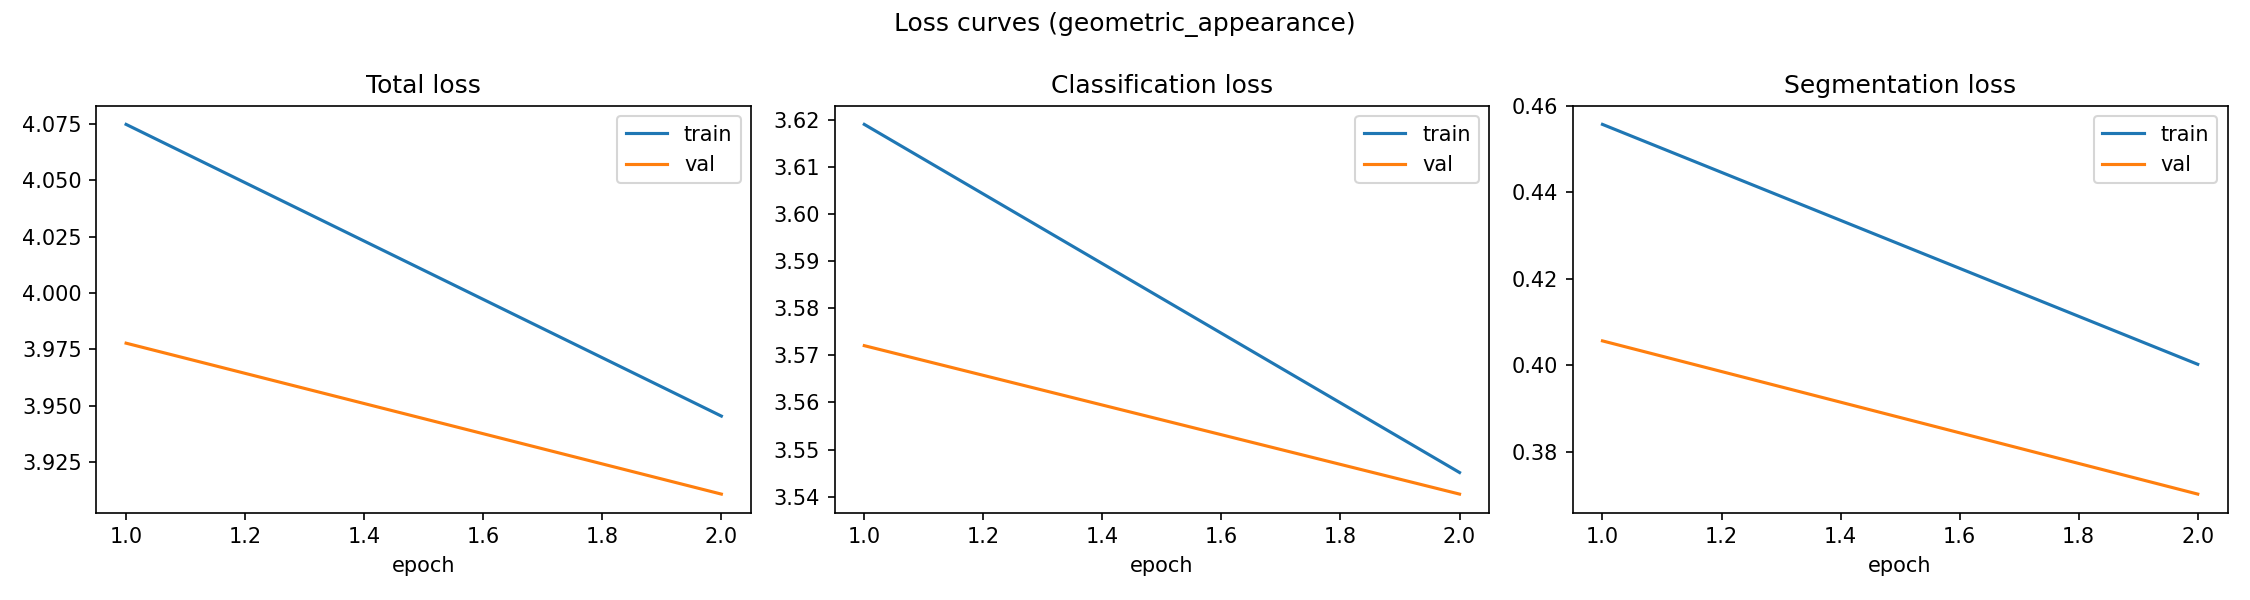

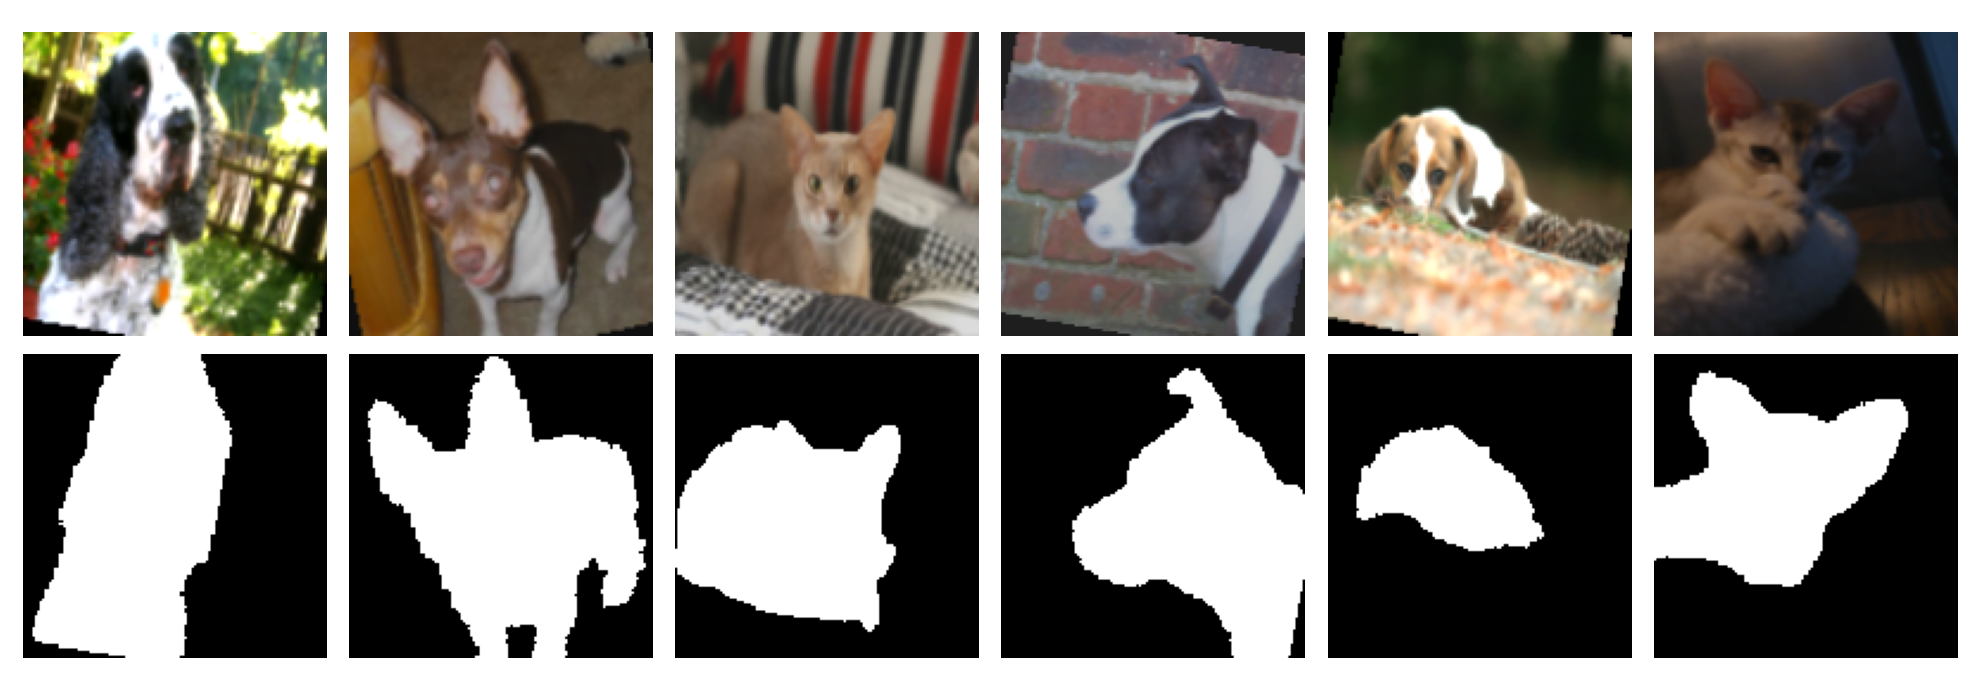

In [11]:
for subdir in ["expA_baseline", "expB_geometric", "expC_geometric_appearance"]:
    d = OUT_DIR / subdir
    if not d.exists():
        continue
    print(f"=== {subdir} ===")
    display(Image(filename=str(d / "loss_curves.png")))
    aug_path = d / "augmented_examples.png"
    if aug_path.exists():
        display(Image(filename=str(aug_path)))


## 7. Next step

Fill in `REPORT_TEMPLATE.md` using the numbers/plots above -- it already has placeholders for
every section the assignment asks for (a-f, the Q2 table, and the 5 discussion questions). Don't
answer the discussion questions until you've actually looked at these outputs; the assignment
requires conclusions to be supported by your results, not by generic augmentation folklore.